<a href="https://colab.research.google.com/github/Carlosjara01/Inteligencia-Artificial/blob/main/transformers_11052026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Instalación de librerías

In [23]:
# ============================================================
# PROYECTO:
# Clasificación de textos con Transformers (DistilBERT/BERT)
# ============================================================

# ============================================================
# SECCIÓN 1 — INSTALACIÓN DE LIBRERÍAS
# ============================================================

# Instalamos las librerías necesarias para trabajar con:
# - Transformers
# - Machine Learning
# - Visualización
# - Procesamiento numérico

!pip install transformers torch scikit-learn matplotlib seaborn pandas numpy -q

Importaciones

In [24]:
# ============================================================
# SECCIÓN 2 — IMPORTACIONES
# ============================================================

# Torch:
# Librería principal de Deep Learning utilizada por HuggingFace
import torch

# NumPy:
# Permite trabajar con arreglos y operaciones matemáticas
import numpy as np

# Pandas:
# Utilizado para manejo de tablas y datasets
import pandas as pd

# Matplotlib:
# Librería para gráficos
import matplotlib.pyplot as plt

# Seaborn:
# Librería avanzada de visualización basada en matplotlib
import seaborn as sns

# pipeline:
# Permite usar modelos preentrenados fácilmente
from transformers import pipeline

# AutoTokenizer:
# Convierte texto en tokens entendibles por el Transformer
from transformers import AutoTokenizer

# AutoModel:
# Carga el modelo Transformer
from transformers import AutoModel

# cosine_similarity:
# Calcula similitud entre vectores
from sklearn.metrics.pairwise import cosine_similarity

DESCRIPCIÓN DEL MODELO

In [25]:
# ============================================================
# SECCIÓN 3 — DESCRIPCIÓN DEL MODELO
# ============================================================

"""
MODELO UTILIZADO:
DistilBERT

¿POR QUÉ DISTILBERT?

- Es una versión optimizada y liviana de BERT.
- Consume menos memoria RAM.
- Es más rápido.
- Ideal para Google Colab.
- Mantiene buena precisión en NLP.

DIFERENCIA ENTRE BERT Y DISTILBERT:

BERT:
- Más grande
- Más preciso
- Más pesado

DistilBERT:
- Más rápido
- Más eficiente
- Menor consumo de recursos

En proyectos académicos normalmente DistilBERT es suficiente.
"""

'\nMODELO UTILIZADO:\nDistilBERT\n\n¿POR QUÉ DISTILBERT?\n\n- Es una versión optimizada y liviana de BERT.\n- Consume menos memoria RAM.\n- Es más rápido.\n- Ideal para Google Colab.\n- Mantiene buena precisión en NLP.\n\nDIFERENCIA ENTRE BERT Y DISTILBERT:\n\nBERT:\n- Más grande\n- Más preciso\n- Más pesado\n\nDistilBERT:\n- Más rápido\n- Más eficiente\n- Menor consumo de recursos\n\nEn proyectos académicos normalmente DistilBERT es suficiente.\n'

 CARGA DEL MODELO DE SENTIMIENTOS

In [26]:
# ============================================================
# SECCIÓN 4 — CARGA DEL MODELO DE SENTIMIENTOS
# ============================================================

# pipeline():
# Permite usar un modelo preentrenado de forma sencilla.

# sentiment-analysis:
# Tarea NLP que clasifica emociones o sentimientos.

# model:
# Modelo multilingüe entrenado para análisis de sentimientos.

clasificador = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FUNCIÓN PARA CONVERTIR RESULTADOS

In [27]:
# ============================================================
# SECCIÓN 5 — FUNCIÓN PARA CONVERTIR RESULTADOS
# ============================================================

# Esta función convierte las estrellas del modelo
# en categorías más entendibles:
# Positivo, Negativo o Neutral.

def convertir_sentimiento(resultado):

    # El modelo devuelve etiquetas tipo:
    # "1 star", "5 stars", etc.
    etiqueta = resultado["label"]

    # score:
    # nivel de confianza del modelo
    score = resultado["score"]

    # Extraemos el número inicial
    estrellas = int(etiqueta[0])

    # Clasificación manual
    if estrellas <= 2:
        sentimiento = "Negativo"

    elif estrellas == 3:
        sentimiento = "Neutral"

    else:
        sentimiento = "Positivo"

    # Retornamos:
    # sentimiento, confianza y estrellas
    return sentimiento, score, estrellas

FUNCIÓN PRINCIPAL DE CLASIFICACIÓN

In [28]:
# ============================================================
# SECCIÓN 6 — FUNCIÓN PRINCIPAL DE CLASIFICACIÓN
# ============================================================

def clasificar_texto(texto):

    # El modelo acepta máximo cierta cantidad de tokens.
    # Por seguridad limitamos el texto.
    resultado = clasificador(texto[:512])[0]

    # Convertimos el resultado
    sentimiento, confianza, estrellas = convertir_sentimiento(resultado)

    # Mostramos información
    print("====================================")
    print("TEXTO ANALIZADO")
    print("====================================")
    print(texto)

    print("\n====================================")
    print("RESULTADO")
    print("====================================")

    print(f"Clasificación: {sentimiento}")

    # :.2% convierte decimal a porcentaje
    print(f"Confianza: {confianza:.2%}")

    print(f"Estrellas detectadas: {estrellas}")

    # Retornamos valores
    return sentimiento, confianza, estrellas

EJEMPLOS DE CLASIFICACIÓN

In [29]:
# ============================================================
# SECCIÓN 7 — EJEMPLOS DE CLASIFICACIÓN
# ============================================================

# Texto positivo
texto_1 = "La película fue increíble y la actuación excelente."

# Texto negativo
texto_2 = "El sistema presentó múltiples errores y fue decepcionante."

# Texto neutral
texto_3 = "El proyecto fue entregado correctamente."

# Ejecutamos clasificación
clasificar_texto(texto_1)

TEXTO ANALIZADO
La película fue increíble y la actuación excelente.

RESULTADO
Clasificación: Positivo
Confianza: 74.43%
Estrellas detectadas: 5


('Positivo', 0.7442642450332642, 5)

In [21]:
# Clasificación negativa
clasificar_texto(texto_2)

TEXTO ANALIZADO
El sistema presentó múltiples errores y fue decepcionante.

RESULTADO
Clasificación: Negativo
Confianza: 61.31%
Estrellas detectadas: 1


('Negativo', 0.6130644679069519, 1)

In [30]:
# Clasificación neutral
clasificar_texto(texto_3)

TEXTO ANALIZADO
El proyecto fue entregado correctamente.

RESULTADO
Clasificación: Positivo
Confianza: 46.42%
Estrellas detectadas: 4


('Positivo', 0.4642188847064972, 4)

TEXTOS LARGOS (UNO O MÁS PÁRRAFOS)

In [31]:
# ============================================================
# SECCIÓN 8 — TEXTOS LARGOS (UNO O MÁS PÁRRAFOS)
# ============================================================

texto_largo = """
Estoy feliz porque he finalizado un proyecto importante de inteligencia artificial.

Durante el desarrollo aprendí sobre transformers,
embeddings, atención y clasificación de textos.

Aunque al principio fue complejo,
el resultado final fue muy satisfactorio.
"""

# Analizamos el texto largo
clasificar_texto(texto_largo)

TEXTO ANALIZADO

Estoy feliz porque he finalizado un proyecto importante de inteligencia artificial.

Durante el desarrollo aprendí sobre transformers,
embeddings, atención y clasificación de textos.

Aunque al principio fue complejo,
el resultado final fue muy satisfactorio.


RESULTADO
Clasificación: Positivo
Confianza: 58.62%
Estrellas detectadas: 4


('Positivo', 0.5861776471138, 4)

CARGA DE DISTILBERT

In [32]:
# ============================================================
# SECCIÓN 9 — CARGA DE DISTILBERT
# ============================================================

# Modelo para embeddings y atención
modelo_embedding = "distilbert-base-multilingual-cased"

# Tokenizer:
# Convierte palabras a tokens
tokenizer = AutoTokenizer.from_pretrained(modelo_embedding)

# Modelo Transformer
# output_attentions=True:
# permite obtener matrices de atención
modelo = AutoModel.from_pretrained(
    modelo_embedding,
    output_attentions=True
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TOKENIZACIÓN

In [33]:
# ============================================================
# SECCIÓN 10 — TOKENIZACIÓN
# ============================================================

texto = "La película fue increíble"

# tokenizer():
# Convierte texto en tokens numéricos

tokens = tokenizer(

    # Texto de entrada
    texto,

    # Devuelve tensores de PyTorch
    return_tensors="pt",

    # Completa secuencias cortas
    padding=True,

    # Recorta secuencias largas
    truncation=True
)

# Mostramos tokens
print(tokens)

{'input_ids': tensor([[  101, 10159, 14970, 10553, 10106, 27794, 10545, 11203,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}


CONVERSIÓN DE IDS A PALABRAS

In [34]:
# ============================================================
# CONVERSIÓN DE IDS A PALABRAS
# ============================================================

# input_ids:
# contiene IDs numéricos

# convert_ids_to_tokens():
# convierte IDs nuevamente a palabras

tokens_texto = tokenizer.convert_ids_to_tokens(
    tokens["input_ids"][0]
)

print(tokens_texto)

['[CLS]', 'La', 'película', 'fue', 'in', '##cre', '##í', '##ble', '[SEP]']


OBTENER EMBEDDINGS

In [35]:
# ============================================================
# SECCIÓN 11 — OBTENER EMBEDDINGS
# ============================================================

# torch.no_grad():
# desactiva entrenamiento
# y reduce consumo de memoria

with torch.no_grad():

    # Procesamos tokens en el modelo
    salida = modelo(**tokens)

# last_hidden_state:
# embeddings finales del Transformer
embeddings = salida.last_hidden_state

print("Dimensiones del embedding:")
print(embeddings.shape)

Dimensiones del embedding:
torch.Size([1, 9, 768])


EXPLICACIÓN DEL RESULTADO

In [36]:
# ============================================================
# EXPLICACIÓN DEL RESULTADO
# ============================================================

"""
Ejemplo:
torch.Size([1, 6, 768])

SIGNIFICA:

1  -> cantidad de textos
6  -> cantidad de tokens
768 -> dimensiones del embedding

Cada palabra termina convertida
en un vector matemático de 768 dimensiones.
"""

'\nEjemplo:\ntorch.Size([1, 6, 768])\n\nSIGNIFICA:\n\n1  -> cantidad de textos\n6  -> cantidad de tokens\n768 -> dimensiones del embedding\n\nCada palabra termina convertida\nen un vector matemático de 768 dimensiones.\n'

MATRICES DE ATENCIÓN

In [37]:
# ============================================================
# SECCIÓN 12 — MATRICES DE ATENCIÓN
# ============================================================

# attentions:
# contiene información de qué palabras
# prestan atención a otras palabras

attentions = salida.attentions

print("Cantidad de capas:")
print(len(attentions))

print("\nForma de una capa:")
print(attentions[0].shape)

Cantidad de capas:
6

Forma de una capa:
torch.Size([1, 12, 9, 9])


EXPLICACIÓN

In [38]:
# ============================================================
# EXPLICACIÓN
# ============================================================

"""
Forma típica:

[batch_size, heads, tokens, tokens]

Ejemplo:

[1, 12, 6, 6]

1  -> cantidad de textos
12 -> cabezas de atención
6  -> tokens
6  -> relación token-token

Cada palabra analiza a las demás.
"""

'\nForma típica:\n\n[batch_size, heads, tokens, tokens]\n\nEjemplo:\n\n[1, 12, 6, 6]\n\n1  -> cantidad de textos\n12 -> cabezas de atención\n6  -> tokens\n6  -> relación token-token\n\nCada palabra analiza a las demás.\n'

HEATMAP DE ATENCIÓN

In [39]:
# ============================================================
# SECCIÓN 13 — HEATMAP DE ATENCIÓN
# ============================================================

def visualizar_atencion(texto, capa=0, cabeza=0):

    # Convertimos texto en tokens
    inputs = tokenizer(
        texto,
        return_tensors="pt",
        truncation=True
    )

    # Inferencia sin entrenamiento
    with torch.no_grad():
        outputs = modelo(**inputs)

    # Recuperamos tokens
    tokens = tokenizer.convert_ids_to_tokens(
        inputs["input_ids"][0]
    )

    # Seleccionamos atención
    attention = outputs.attentions[capa][0, cabeza].numpy()

    # Tamaño del gráfico
    plt.figure(figsize=(10,8))

    # Heatmap
    sns.heatmap(

        attention,

        # Etiquetas horizontales
        xticklabels=tokens,

        # Etiquetas verticales
        yticklabels=tokens,

        # Paleta de colores
        cmap="viridis",

        annot=False
    )

    plt.title(
        f"Mapa de atención - Capa {capa} - Cabeza {cabeza}"
    )

    plt.xlabel("Palabras atendidas")
    plt.ylabel("Palabras que atienden")

    plt.show()

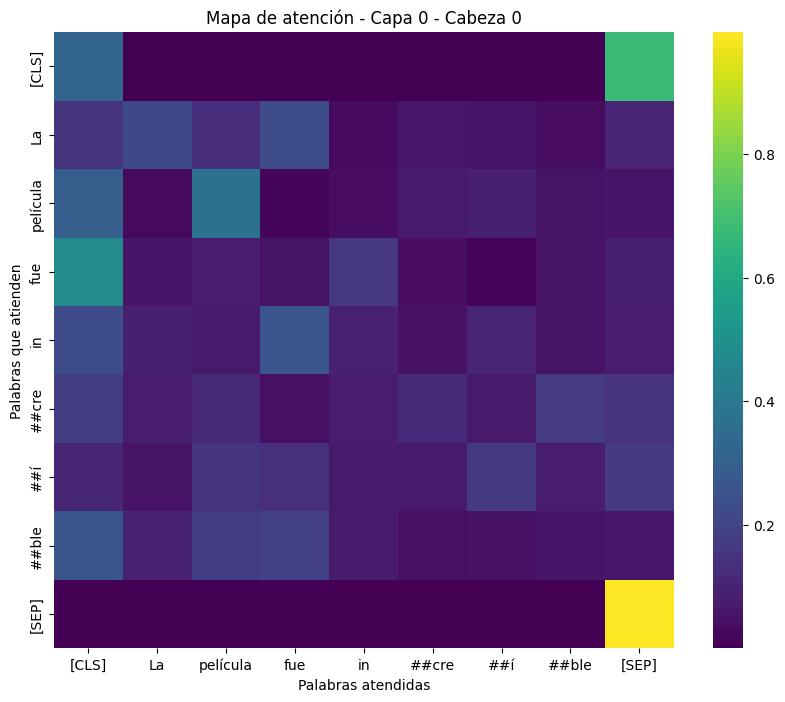

In [40]:
# Ejecutamos visualización
visualizar_atencion(
    "La película fue increíble"
)

EMBEDDING DE FRASES

In [41]:
# ============================================================
# SECCIÓN 14 — EMBEDDING DE FRASES
# ============================================================

def obtener_embedding_frase(texto):

    # Tokenización
    inputs = tokenizer(
        texto,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    # Inferencia
    with torch.no_grad():
        outputs = modelo(**inputs)

    # mean(dim=1):
    # promedio de embeddings
    embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding.numpy()

COMPARACIÓN DE FRASES

In [42]:
# ============================================================
# SECCIÓN 15 — COMPARACIÓN DE FRASES
# ============================================================

def comparar_frases(frase1, frase2):

    # Obtenemos embeddings
    emb1 = obtener_embedding_frase(frase1)
    emb2 = obtener_embedding_frase(frase2)

    # cosine_similarity():
    # mide similitud matemática
    similitud = cosine_similarity(
        emb1,
        emb2
    )[0][0]

    print("===================================")
    print("COMPARACIÓN")
    print("===================================")

    print("Frase 1:")
    print(frase1)

    print("\nFrase 2:")
    print(frase2)

    print(f"\nSimilitud: {similitud:.2%}")

    return similitud

In [22]:
# Frases similares
comparar_frases(
    "La película fue increíble",
    "El filme fue excelente"
)

COMPARACIÓN
Frase 1:
La película fue increíble

Frase 2:
El filme fue excelente

Similitud: 78.29%


np.float32(0.7828541)

In [43]:
# Frases diferentes
comparar_frases(
    "La película fue increíble",
    "El sistema tuvo muchos errores"
)

COMPARACIÓN
Frase 1:
La película fue increíble

Frase 2:
El sistema tuvo muchos errores

Similitud: 60.92%


np.float32(0.6091887)

### SECCIÓN 16 — SIMULACIÓN DE CURVAS DE ENTRENAMIENTO
En esta sección simulamos el comportamiento de la pérdida (Loss) y la precisión (Accuracy) durante el entrenamiento de un modelo de sentimientos.

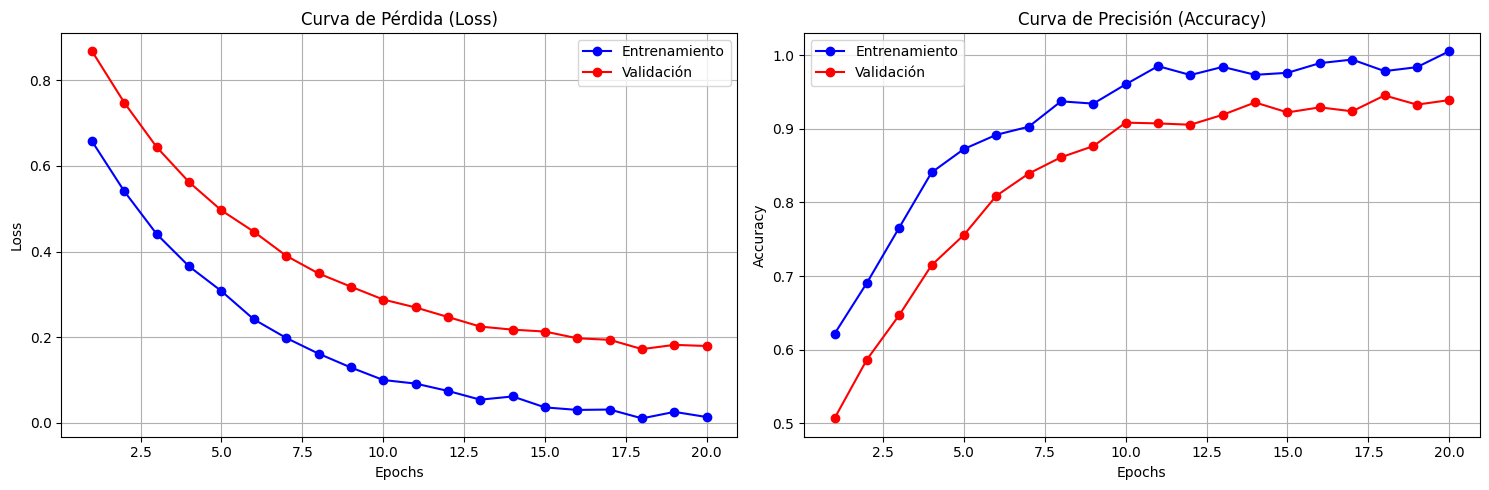

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de la simulación
epochs = np.arange(1, 21)
train_loss = 0.8 * np.exp(-0.2 * epochs) + 0.1 * np.random.normal(0, 0.05, len(epochs))
val_loss = 0.85 * np.exp(-0.18 * epochs) + 0.15 + 0.1 * np.random.normal(0, 0.05, len(epochs))

train_acc = 1 - 0.5 * np.exp(-0.25 * epochs) + np.random.normal(0, 0.01, len(epochs))
val_acc = 1 - 0.55 * np.exp(-0.22 * epochs) - 0.05 + np.random.normal(0, 0.01, len(epochs))

# Creación de la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de Pérdida (Loss)
ax1.plot(epochs, train_loss, 'bo-', label='Entrenamiento')
ax1.plot(epochs, val_loss, 'ro-', label='Validación')
ax1.set_title('Curva de Pérdida (Loss)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Gráfico de Precisión (Accuracy)
ax2.plot(epochs, train_acc, 'bo-', label='Entrenamiento')
ax2.plot(epochs, val_acc, 'ro-', label='Validación')
ax2.set_title('Curva de Precisión (Accuracy)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()